# Denoising Method Comparison — POC_DDM

Compares **five** denoising methods on raw kinetic (LAMP/DDM) curves:

| # | Method | Key hyperparameter |
|---|---|---|
| 1 | Moving avg (`ori_curves_avg`) | `config.WINDOW_SIZE_ORI` |
| 2 | Wavelet (universal threshold) | `WAVELETS[0]`, `LEVEL`, `THRESH_MODE` |
| 3 | Savitzky-Golay | `SG_POLYORDER`, `SG_OPTIMAL_W` (auto-detected) |
| 4 | FFT low-pass | `FFT_CUTOFF` (auto-detected) |
| 5 | Gaussian | `GAUSS_SIGMA` (auto-detected) |

Hyperparameters for SG, FFT, and Gaussian are auto-selected via the same derivative-test sweep; each can be overridden in the *Apply* cell.

In [1]:
import os, sys, time, tracemalloc
import numpy as np
import matplotlib.pyplot as plt
import joblib
import pywt
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter1d, uniform_filter1d

sys.path.insert(0, '/vol/bitbucket/gk225/POC_DDM/gk_code')
sys.path.insert(0, '/vol/bitbucket/gk225/POC_DDM/gk_code/main')
import config

try:
    from tqdm import tqdm
except ImportError:
    tqdm = None

print(f'pywt {pywt.__version__} | base: {config.BASE_FOLDER}')


[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0

pywt 1.8.0 | base: /vol/bitbucket/gk225/POC_DDM_datasets


In [2]:
# ── Configuration ─────────────────────────────────────────────
DATASET      = 'POC_DDM_final_nc_subtract'   # or 'POC_DDM_multi'
EXP_FOLDER   = os.path.join(config.BASE_FOLDER, DATASET)
CURVE_TYPE   = 'ori_curves'
WAVELETS     = ['sym8']          # first entry used in comparison
LEVEL        = None
THRESH_MODE  = 'soft'
SG_POLYORDER = 2                 # 2 = quadratic, 3 = cubic

In [3]:
# ── Wavelet ────────────────────────────────────────────────────────────────
def denoise_curve(curve, wavelet, level=LEVEL, mode=THRESH_MODE):
    coeffs     = pywt.wavedec(curve, wavelet, level=level)
    sigma      = np.median(np.abs(coeffs[-1])) / 0.6745
    threshold  = sigma * np.sqrt(2 * np.log(len(curve)))
    new_coeffs = [coeffs[0]] + [pywt.threshold(d, threshold, mode=mode) for d in coeffs[1:]]
    return pywt.waverec(new_coeffs, wavelet)[:len(curve)]

def denoise_all(curves, wavelet):
    it = tqdm(curves, desc=f'Denoising [{wavelet}]', unit='curve') if tqdm else curves
    return np.array([denoise_curve(c, wavelet) for c in it])

# ── SG ─────────────────────────────────────────────────────────────────────────────
def _ensure_odd(w): return w + (1 - w % 2)

def apply_sg(curves, window_length, polyorder):
    w = _ensure_odd(int(window_length)); w = max(w, polyorder + 2)
    return savgol_filter(curves, window_length=w, polyorder=polyorder, axis=1)

# ── FFT ─────────────────────────────────────────────────────────────────────────────
def denoise_fft(curves, cutoff_frac):
    T = curves.shape[1]; cutoff_k = max(1, int(cutoff_frac * (T // 2 + 1)))
    X = np.fft.rfft(curves, axis=1); X[:, cutoff_k:] = 0
    return np.fft.irfft(X, n=T, axis=1)

# ── Gaussian ──────────────────────────────────────────────────────────────────────
def denoise_gaussian(curves, sigma):
    return gaussian_filter1d(curves.astype(float), sigma=sigma, axis=1)

# ── Shared sweep utilities ─────────────────────────────────────────────────────
def detect_positive_wells(curves, well_labels, label_map=None, rise_frac=0.20):
    if label_map:
        return [w for w in sorted(np.unique(well_labels))
                if not label_map.get(int(w), '').startswith('NC')]
    drange = curves.max() - curves.min()
    return [w for w in sorted(np.unique(well_labels))
            if curves[well_labels == w].mean(axis=0).ptp() > rise_frac * drange]

def estimate_takeoff_width(curves, well_labels, label_map=None, smooth_w=15, thr=0.15):
    pos = detect_positive_wells(curves, well_labels, label_map=label_map)
    if not pos: return None, None
    kernel = np.ones(smooth_w) / smooth_w; widths = []
    for c in curves[np.isin(well_labels, pos)]:
        d = np.abs(np.diff(np.convolve(c, kernel, mode='same')))
        active = np.where(d > thr * d.max())[0]
        if len(active) >= 2: widths.append(int(active[-1] - active[0]))
    return (float(np.mean(widths)), np.array(widths)) if widths else (None, None)

def _derivative_scores(curves, param_values, denoise_fn, sample_size=400, seed=0):
    rng    = np.random.default_rng(seed)
    sample = curves[rng.choice(len(curves), size=min(sample_size, len(curves)), replace=False)]
    ref    = savgol_filter(sample, window_length=5, polyorder=2, axis=1)
    peak_r = np.abs(np.diff(ref, axis=1)).max(axis=1)
    ro_raw = np.std(np.diff(np.diff(sample, axis=1), axis=1), axis=1)
    prs, ros = [], []
    for p in param_values:
        df = np.diff(denoise_fn(sample, p), axis=1)
        prs.append(np.mean(np.abs(df).max(axis=1) / np.where(peak_r > 0, peak_r, 1)))
        ros.append(np.mean(np.std(np.diff(df, axis=1), axis=1) / np.where(ro_raw > 0, ro_raw, 1)))
    return np.array(prs), np.array(ros)

def _sweet_spot(param_values, roughnesses):
    floor = np.percentile(roughnesses, 10)
    sweet = np.where(roughnesses <= 2.0 * floor)[0]
    return float(param_values[sweet[0]] if len(sweet) else param_values[np.argmin(roughnesses)])

def _sweep_plot(param_values, prs, ros, sweet, xlabel, title_prefix, color):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    fig.suptitle(f'{title_prefix}  |  derivative-test sweep', fontsize=11, fontweight='bold')
    for ax, vals, ylab, yref in [
        (axes[0], prs, 'Peak ratio  (↑ → 1.0)', 0.80),
        (axes[1], ros, 'Roughness  (↓ → 0)',    2.0 * np.percentile(ros, 10)),
    ]:
        ax.plot(param_values, vals, color=color, lw=1.5)
        ax.axhline(yref,  color='gray', ls='--', lw=1, label=f'{yref:.2f} ref')
        ax.axvline(sweet, color='#D55E00', ls='--', lw=1.5, label=f'sweet-spot {sweet:.4g}')
        ax.set_xlabel(xlabel); ax.set_ylabel(ylab)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
    return fig, axes

# ── Benchmark ──────────────────────────────────────────────────────────────────────
def benchmark_method(fn, curves, n_repeats=2):
    times, peak_mb = [], 0.0
    for _ in range(n_repeats):
        tracemalloc.start()
        t0 = time.perf_counter(); fn(curves); elapsed = time.perf_counter() - t0
        _, peak = tracemalloc.get_traced_memory(); tracemalloc.stop()
        times.append(elapsed); peak_mb = max(peak_mb, peak / 1e6)
    return float(np.mean(times)), peak_mb

# ── Data loading ────────────────────────────────────────────────────────────────
def list_folders(exp_folder):
    out = []
    for name in sorted(os.listdir(exp_folder)):
        p = os.path.join(exp_folder, name)
        if (os.path.isdir(p) and name not in config.EXCLUDED_FOLDERS
                and os.path.exists(os.path.join(p, config.TRAINING_DATA_PATH))):
            out.append((name, p))
    return out

def load_exp(folder_path):
    d           = joblib.load(os.path.join(folder_path, config.TRAINING_DATA_PATH))
    curves      = np.array(d['curves'][CURVE_TYPE])
    curves_avg  = np.array(d['curves']['ori_curves_avg'])
    well_labels = np.array(d['well_labels'])
    return curves, curves_avg, well_labels

print('All functions loaded.')

All functions loaded.


In [4]:
label_maps = config.get_label_mappings(EXP_FOLDER)
results    = {}
folders    = list_folders(EXP_FOLDER)

print(f'{DATASET}: {len(folders)} folders')
for folder_name, folder_path in folders:
    print(f'\n─── {folder_name} ───')
    try:
        raw, smoothed, well_labels = load_exp(folder_path)
        print(f'  {raw.shape}')
        results[folder_name] = {
            'raw':         raw,
            'smoothed':    smoothed,
            'denoised':    {w: denoise_all(raw, wavelet=w) for w in WAVELETS},
            'well_labels': well_labels,
            'label_map':   label_maps.get(folder_name, {}),
        }
    except Exception as e:
        print(f'  [ERROR] {e}')

POC_DDM_final_nc_subtract: 2 folders

─── D20260731_E00_C00_F4500KHz_U_DDM_01_01 ───
  (18667, 775)


Denoising [sym8]: 100%|██████████| 18667/18667 [00:03<00:00, 5319.11curve/s]



─── D20260731_E00_C00_F4500KHz_U_DDM_01_04 ───
  (18094, 405)


Denoising [sym8]:   0%|          | 0/18094 [00:00<?, ?curve/s]/vol/bitbucket/gk225/venv_poc_ddm/lib/python3.12/site-packages/pywt/_thresholding.py:22: RuntimeWarning: invalid value encountered in divide
  thresholded = (1 - value/magnitude)
Denoising [sym8]: 100%|██████████| 18094/18094 [00:02<00:00, 6476.35curve/s]


---
## Savitzky-Golay Smoothing

Fits a polynomial of degree $p$ to each sliding window of $w$ points.
Unlike moving average ($p=1$), it preserves peaks and the S-curve shape.

**Derivative test** — sweet spot: smallest $w$ where roughness levels off at its floor.

| Score | Formula | Target |
|---|---|---|
| Peak ratio | $\\max|d_\\text{filt}|/\\max|d_\\text{raw}|$ | → 1.0 |
| Roughness | $\\sigma(\\Delta d_\\text{filt})/\\sigma(\\Delta d_\\text{raw})$ | → 0 |

D20260731_E00_C00_F4500KHz_U_DDM_01_01:  takeoff ≈ 760 pts  →  suggested w: 75–151
D20260731_E00_C00_F4500KHz_U_DDM_01_04:  takeoff ≈ 397 pts  →  suggested w: 39–79

Sweeping SG on "D20260731_E00_C00_F4500KHz_U_DDM_01_04" (16380 positive curves) ...
Auto sweet-spot →  SG_OPTIMAL_W = 73


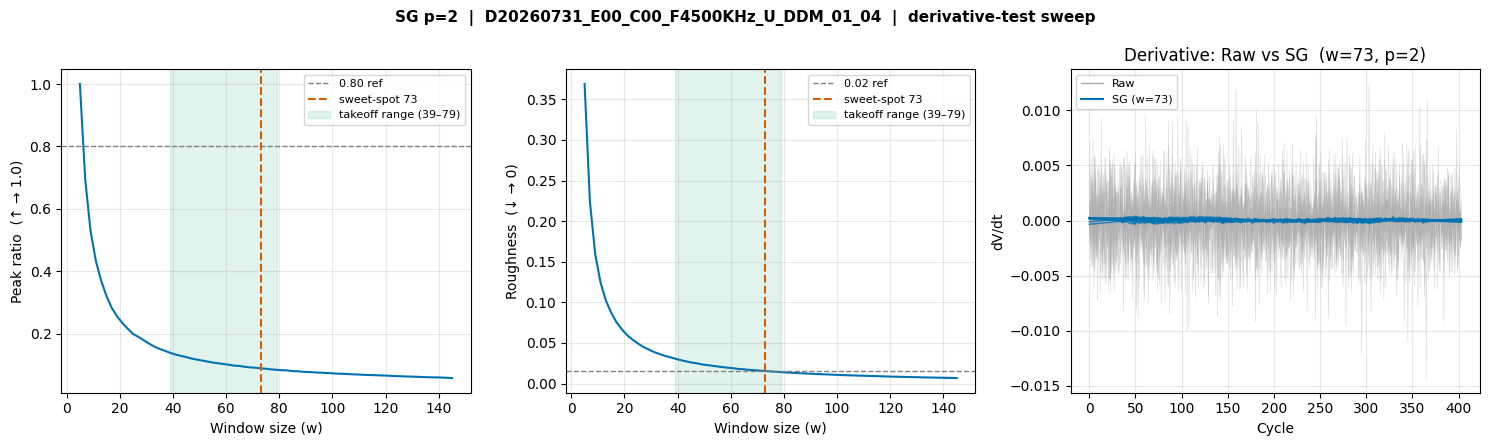

In [5]:
# ── SG sweep: takeoff width + derivative-test ──────────────────────────────────
WINDOW_SEARCH_MIN = 5
WINDOW_SEARCH_MAX = 145
candidate_windows = np.arange(_ensure_odd(WINDOW_SEARCH_MIN), WINDOW_SEARCH_MAX + 1, 2)

for folder_name, _ in folders:
    if folder_name not in results: continue
    r = results[folder_name]
    mean_w, _ = estimate_takeoff_width(r['raw'], r['well_labels'], label_map=r['label_map'])
    if mean_w:
        wl = _ensure_odd(max(5, int(mean_w * 0.10))); wh = _ensure_odd(int(mean_w * 0.20))
        print(f'{folder_name}:  takeoff ≈ {mean_w:.0f} pts  →  suggested w: {wl}–{wh}')
    else: print(f'{folder_name}: [!] no positive wells')

_sw = list(results.keys())[1]; _r = results[_sw]
_pc = _r['raw'][np.isin(_r['well_labels'],
      detect_positive_wells(_r['raw'], _r['well_labels'], label_map=_r['label_map']))]
print(f'\nSweeping SG on "{_sw}" ({len(_pc)} positive curves) ...')
sg_pr, sg_ro = _derivative_scores(_pc, candidate_windows,
                                   lambda c, w: apply_sg(c, int(w), SG_POLYORDER))
SG_OPTIMAL_W = _ensure_odd(int(_sweet_spot(candidate_windows, sg_ro)))
print(f'Auto sweet-spot →  SG_OPTIMAL_W = {SG_OPTIMAL_W}')

fig, axes = _sweep_plot(candidate_windows, sg_pr, sg_ro, SG_OPTIMAL_W,
                        'Window size (w)', f'SG p={SG_POLYORDER}  |  {_sw}', '#0072B2')
_mw, _ = estimate_takeoff_width(_r['raw'], _r['well_labels'], label_map=_r['label_map'])
if _mw:
    _wl = _ensure_odd(max(5, int(_mw*0.10))); _wh = _ensure_odd(int(_mw*0.20))
    for ax in axes[:2]:
        ax.axvspan(_wl, _wh, alpha=0.12, color='#009E73', label=f'takeoff range ({_wl}–{_wh})')
        ax.legend(fontsize=8)
ax = axes[2]
_rng = np.random.default_rng(42)
_idx = _rng.choice(len(_pc), size=min(10, len(_pc)), replace=False)
_filt = apply_sg(_pc[_idx], SG_OPTIMAL_W, SG_POLYORDER)
_t    = np.arange(_pc.shape[1] - 1)
ax.plot(_t, np.diff(_pc[_idx], axis=1).T, color='#AAAAAA', lw=0.5, alpha=0.4)
ax.plot(_t, np.diff(_filt,     axis=1).T, color='#0072B2', lw=1.1, alpha=0.75)
ax.plot([], [], color='#AAAAAA', lw=1, label='Raw')
ax.plot([], [], color='#0072B2', lw=1.5, label=f'SG (w={SG_OPTIMAL_W})')
ax.set_xlabel('Cycle'); ax.set_ylabel('dV/dt')
ax.set_title(f'Derivative: Raw vs SG  (w={SG_OPTIMAL_W}, p={SG_POLYORDER})')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show(); plt.close(fig)

---
## FFT Denoising

Zeros all one-sided spectrum coefficients above `cutoff_frac × (T//2 + 1)`, then reconstructs via `irfft`.

| `cutoff_frac` | Effect |
|---|---|
| 0.02–0.05 | Very aggressive |
| 0.08–0.15 | Typical sweet spot |
| > 0.25 | Permissive |

Sweeping FFT on "D20260731_E00_C00_F4500KHz_U_DDM_01_04" ...
Auto sweet-spot →  FFT_CUTOFF = 0.010


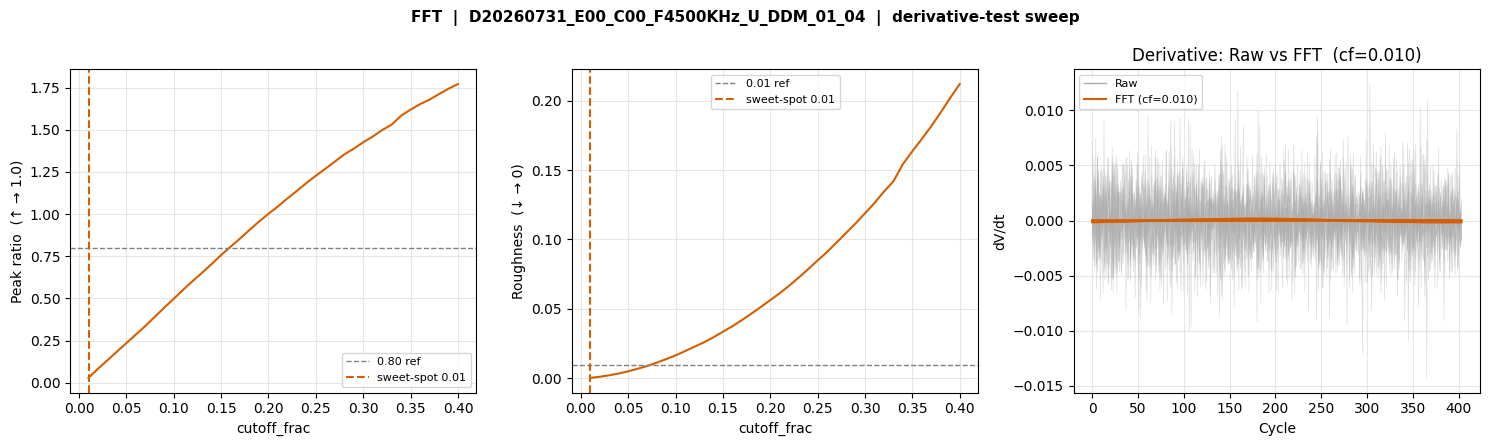

In [6]:
cutoff_fracs = np.linspace(0.01, 0.40, 40)
_fw = list(results.keys())[1]; _r = results[_fw]
_pc = _r['raw'][np.isin(_r['well_labels'],
      detect_positive_wells(_r['raw'], _r['well_labels'], label_map=_r['label_map']))]
print(f'Sweeping FFT on "{_fw}" ...')
fft_pr, fft_ro = _derivative_scores(_pc, cutoff_fracs, denoise_fft, sample_size=400)
FFT_CUTOFF = _sweet_spot(cutoff_fracs, fft_ro)
print(f'Auto sweet-spot →  FFT_CUTOFF = {FFT_CUTOFF:.3f}')

fig, axes = _sweep_plot(cutoff_fracs, fft_pr, fft_ro, FFT_CUTOFF,
                        'cutoff_frac', f'FFT  |  {_fw}', '#D55E00')
_rng = np.random.default_rng(42)
_idx = _rng.choice(len(_pc), size=min(10, len(_pc)), replace=False)
_filt = denoise_fft(_pc[_idx], FFT_CUTOFF); _t = np.arange(_pc.shape[1] - 1)
ax = axes[2]
ax.plot(_t, np.diff(_pc[_idx], axis=1).T, color='#AAAAAA', lw=0.5, alpha=0.4)
ax.plot(_t, np.diff(_filt,     axis=1).T, color='#D55E00', lw=1.1, alpha=0.75)
ax.plot([], [], color='#AAAAAA', lw=1, label='Raw')
ax.plot([], [], color='#D55E00', lw=1.5, label=f'FFT (cf={FFT_CUTOFF:.3f})')
ax.set_xlabel('Cycle'); ax.set_ylabel('dV/dt')
ax.set_title(f'Derivative: Raw vs FFT  (cf={FFT_CUTOFF:.3f})')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show(); plt.close(fig)

---
## Gaussian Smoothing

Applies `scipy.ndimage.gaussian_filter1d` along the time axis.
Standard deviation $\\sigma$ (in cycles) controls the smoothing radius.

| $\\sigma$ | Effect |
|---|---|
| 1–5 | Light — fast-varying noise attenuated |
| 10–30 | Typical sweet spot |
| > 50 | Heavy — peak shape may be affected |

Sweeping Gaussian on "D20260731_E00_C00_F4500KHz_U_DDM_01_04" ...
Auto sweet-spot →  GAUSS_SIGMA = 39.5


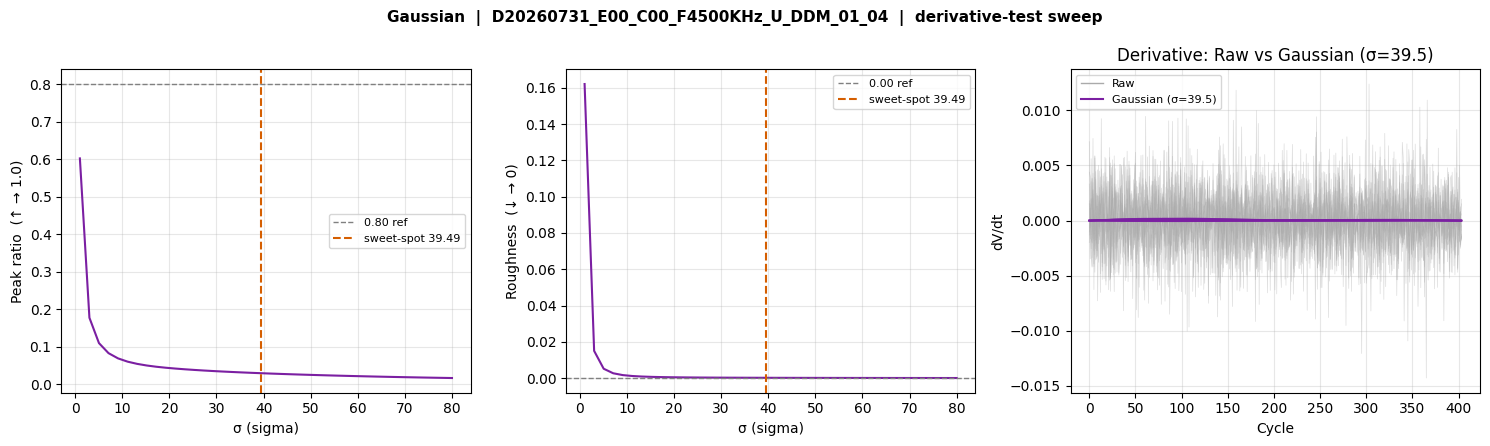

In [7]:
sigma_values = np.linspace(1, 80, 40)
_gw = list(results.keys())[1]; _r = results[_gw]
_pc = _r['raw'][np.isin(_r['well_labels'],
      detect_positive_wells(_r['raw'], _r['well_labels'], label_map=_r['label_map']))]
print(f'Sweeping Gaussian on "{_gw}" ...')
gauss_pr, gauss_ro = _derivative_scores(_pc, sigma_values, denoise_gaussian, sample_size=400)
GAUSS_SIGMA = _sweet_spot(sigma_values, gauss_ro)
print(f'Auto sweet-spot →  GAUSS_SIGMA = {GAUSS_SIGMA:.1f}')

fig, axes = _sweep_plot(sigma_values, gauss_pr, gauss_ro, GAUSS_SIGMA,
                        'σ (sigma)', f'Gaussian  |  {_gw}', '#7B1FA2')
_rng = np.random.default_rng(42)
_idx = _rng.choice(len(_pc), size=min(10, len(_pc)), replace=False)
_filt = denoise_gaussian(_pc[_idx], GAUSS_SIGMA); _t = np.arange(_pc.shape[1] - 1)
ax = axes[2]
ax.plot(_t, np.diff(_pc[_idx], axis=1).T, color='#AAAAAA', lw=0.5, alpha=0.4)
ax.plot(_t, np.diff(_filt,     axis=1).T, color='#7B1FA2', lw=1.1, alpha=0.75)
ax.plot([], [], color='#AAAAAA', lw=1, label='Raw')
ax.plot([], [], color='#7B1FA2', lw=1.5, label=f'Gaussian (σ={GAUSS_SIGMA:.1f})')
ax.set_xlabel('Cycle'); ax.set_ylabel('dV/dt')
ax.set_title(f'Derivative: Raw vs Gaussian (σ={GAUSS_SIGMA:.1f})')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show(); plt.close(fig)

In [8]:
# ── Apply SG, FFT, Gaussian to all datasets ──────────────────────────────────────
# Override auto-detected values here if needed:
# SG_OPTIMAL_W = 21
# FFT_CUTOFF   = 0.05
# GAUSS_SIGMA  = 20.0

print(f'SG    : w={SG_OPTIMAL_W}, p={SG_POLYORDER}')
print(f'FFT   : cutoff_frac={FFT_CUTOFF:.3f}')
print(f'Gauss : sigma={GAUSS_SIGMA:.1f}\n')

for folder_name, _ in folders:
    if folder_name not in results: continue
    raw = results[folder_name]['raw']
    print(f'{folder_name}  ({raw.shape[0]} curves) ...', end=' ', flush=True)
    results[folder_name]['sg']       = apply_sg(raw, SG_OPTIMAL_W, SG_POLYORDER)
    results[folder_name]['fft']      = denoise_fft(raw, FFT_CUTOFF)
    results[folder_name]['gaussian'] = denoise_gaussian(raw, GAUSS_SIGMA)
    print('done.')

print('\nAll methods applied.')

SG    : w=73, p=2
FFT   : cutoff_frac=0.010
Gauss : sigma=39.5

D20260731_E00_C00_F4500KHz_U_DDM_01_01  (18667 curves) ... done.
D20260731_E00_C00_F4500KHz_U_DDM_01_04  (18094 curves) ... done.

All methods applied.


In [9]:
# ── Benchmark: time + peak memory (50 curves, 2 repeats) ───────────────────
_BENCH_N, _BENCH_REPS = 50, 2
METHOD_KEYS = ['smoothed', 'wavelet', 'sg', 'fft', 'gaussian']

print(f'Benchmarking ({_BENCH_N} curves, {_BENCH_REPS} runs) ...\n')
for folder_name, _ in folders:
    if folder_name not in results: continue
    raw = results[folder_name]['raw']
    sample = raw[:min(_BENCH_N, len(raw))]; n_s = len(sample)
    print(f'{folder_name}  ({n_s} × {raw.shape[1]})')
    funcs = [
        ('smoothed', lambda x: uniform_filter1d(x.astype(float), size=config.WINDOW_SIZE_ORI, axis=1)),
        ('wavelet',  lambda x: denoise_all(x, WAVELETS[0])),
        ('sg',       lambda x: apply_sg(x, SG_OPTIMAL_W, SG_POLYORDER)),
        ('fft',      lambda x: denoise_fft(x, FFT_CUTOFF)),
        ('gaussian', lambda x: denoise_gaussian(x, GAUSS_SIGMA)),
    ]
    bench = {}
    for key, func in funcs:
        total_s, peak_mb = benchmark_method(func, sample, n_repeats=_BENCH_REPS)
        ms_per = total_s * 1000 / n_s
        bench[key] = {'ms_per_curve': ms_per, 'peak_mb': peak_mb}
        print(f'  {key:<12}: {ms_per:8.4f} ms/curve   {peak_mb:6.1f} MB peak')
    results[folder_name]['_bench'] = bench
    print()

print('Done.  (Moving avg ≈ uniform_filter1d)')

Benchmarking (50 curves, 2 runs) ...

D20260731_E00_C00_F4500KHz_U_DDM_01_01  (50 × 775)
  smoothed    :   0.0151 ms/curve      0.6 MB peak


Denoising [sym8]: 100%|██████████| 50/50 [00:00<00:00, 1033.68curve/s]


  wavelet     :   1.0769 ms/curve      0.6 MB peak
  sg          :   0.0679 ms/curve      0.4 MB peak
  fft         :   0.0138 ms/curve      1.2 MB peak
  gaussian    :   0.1340 ms/curve      0.6 MB peak

D20260731_E00_C00_F4500KHz_U_DDM_01_04  (50 × 405)
  smoothed    :   0.0024 ms/curve      0.3 MB peak


Denoising [sym8]: 100%|██████████| 50/50 [00:00<00:00, 1597.10curve/s]

  wavelet     :   0.7841 ms/curve      0.4 MB peak
  sg          :   0.0503 ms/curve      0.3 MB peak
  fft         :   0.0049 ms/curve      0.6 MB peak
  gaussian    :   0.0604 ms/curve      0.3 MB peak

Done.  (Moving avg ≈ uniform_filter1d)


---
## All-Methods Comparison

Visual and quantitative comparison of all 5 denoising methods across the same 7 metrics.

### Metric Definitions

| Metric | Formula | Direction | Interpretation |
|---|---|---|---|
| **SNR (dB)** | $10\log_{10}(\mathrm{var}(\hat{x}) / \mathrm{var}(x - \hat{x}))$ | ↑ higher | Signal power vs noise power in dB. Higher = more signal retained relative to noise removed. Curves with zero noise variance are excluded (nan). |
| **Noise %** | $\sigma(x - \hat{x}) \;/\; \mathrm{range}(x) \times 100$ | ↓ lower | Noise amplitude as a percentage of the raw signal's full range. Lower = cleaner. |
| **Fidelity (corr)** | $\rho(x,\; \hat{x})$ | ↑ higher | Pearson correlation between raw and denoised curve. Measures how well the denoised curve tracks the overall shape. |
| **Residual autocorr lag-1** | $\mathrm{corr}(e_t,\; e_{t+1})$ where $e = x - \hat{x}$ | ↓ lower | If residuals are white noise they should be uncorrelated at lag 1 (value near 0). Structured residuals (value > 0) indicate the method is still following noise instead of removing it. |
| **Smoothness ratio TV** | $\mathrm{TV}(\hat{x}) / \mathrm{TV}(x)$ where $\mathrm{TV} = \sum\|\Delta\|$ | ↓ lower | Total variation of the denoised curve relative to the raw. Values well below 1 indicate aggressive smoothing; a value near 1 means little smoothing was applied. |
| **Δ TTP (cycles)** | $\mathrm{mean}\|\mathrm{argmax}(\|d\hat{x}/dt\|) - \mathrm{argmax}(\|dx/dt\|)\|$ | ↓ lower | Mean shift in the estimated time-to-peak (inflection point) between raw and denoised. A good filter should not move the peak. |
| **SD_max ratio** | $\mathrm{mean}(\max\|\dot{\hat{x}}\| \;/\; \max\|\dot{x}\|)$ | → 1.0 | Ratio of the peak first-derivative magnitude after vs before denoising. Close to 1.0 = peak preserved; ≪ 1.0 = peak clipped (over-smoothed). |

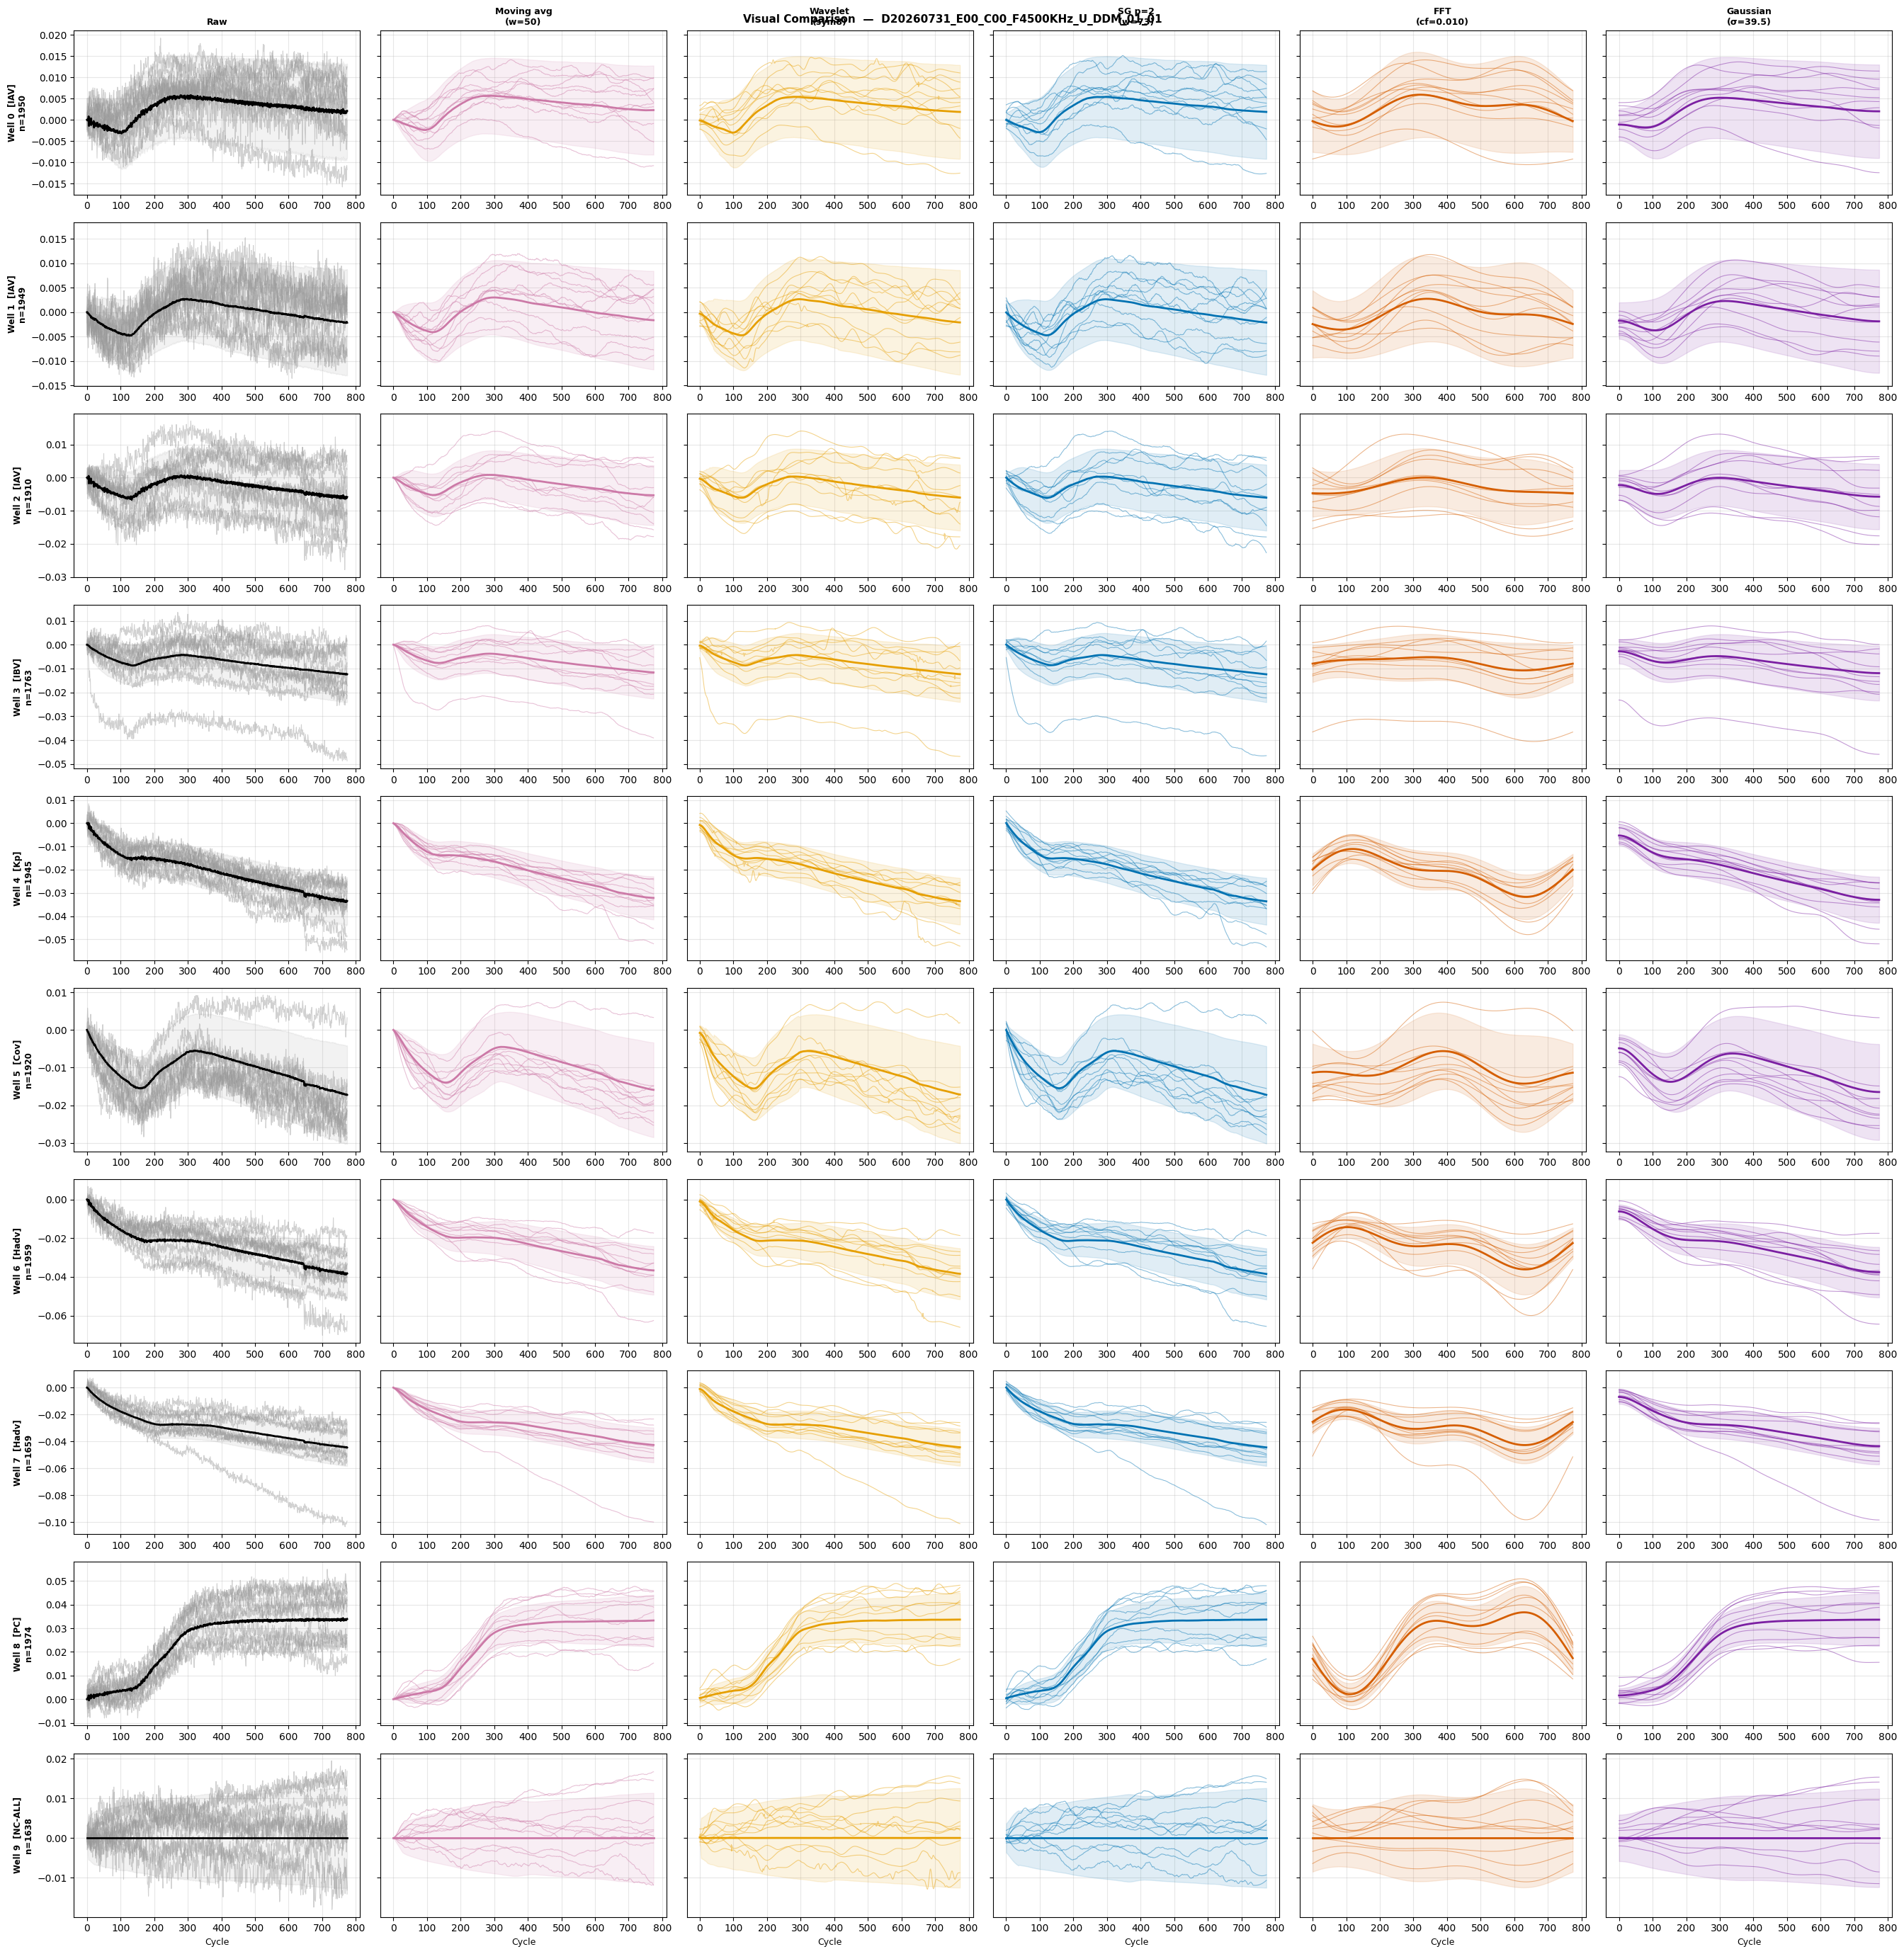

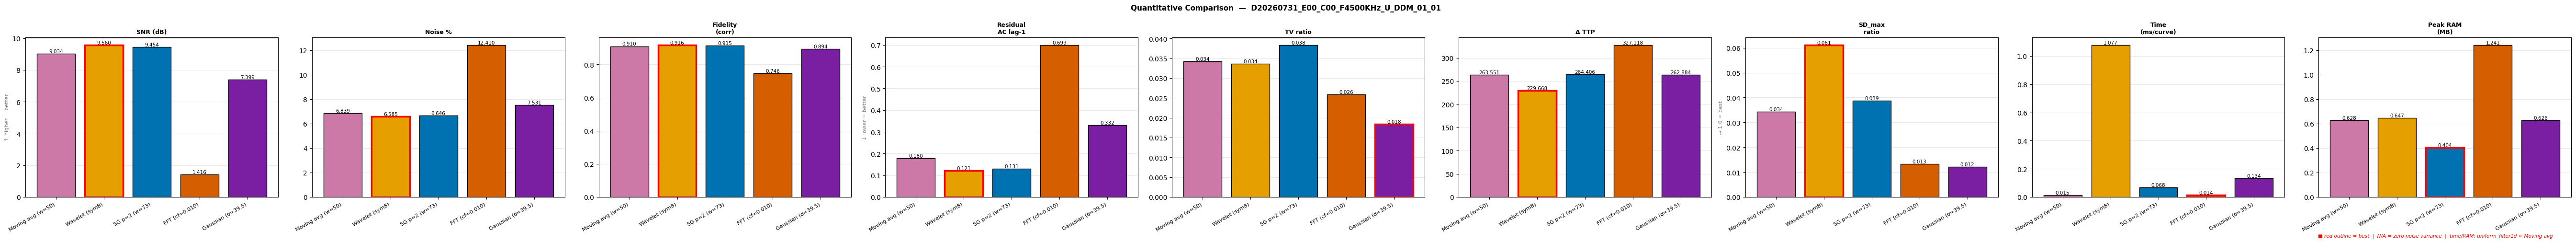


D20260731_E00_C00_F4500KHz_U_DDM_01_01
Metric                      Moving avg (w=50)     Wavelet (sym8)      SG p=2 (w=73)     FFT (cf=0.010)  Gaussian (σ=39.5)
-------------------------------------------------------------------------------------------------------------------------
SNR (dB)                                9.034              *9.560*                9.454                1.416                7.399   ↑
Noise %                                 6.839              *6.585*                6.646               12.410                7.531   ↓
Fidelity (corr)                         0.910              *0.916*                0.915                0.746                0.894   ↑
Residual AC lag-1                       0.180              *0.121*                0.131                0.699                0.332   ↓
TV ratio                                0.034                0.034                0.038                0.026              *0.018*   ↓
Δ TTP                                 263.551 

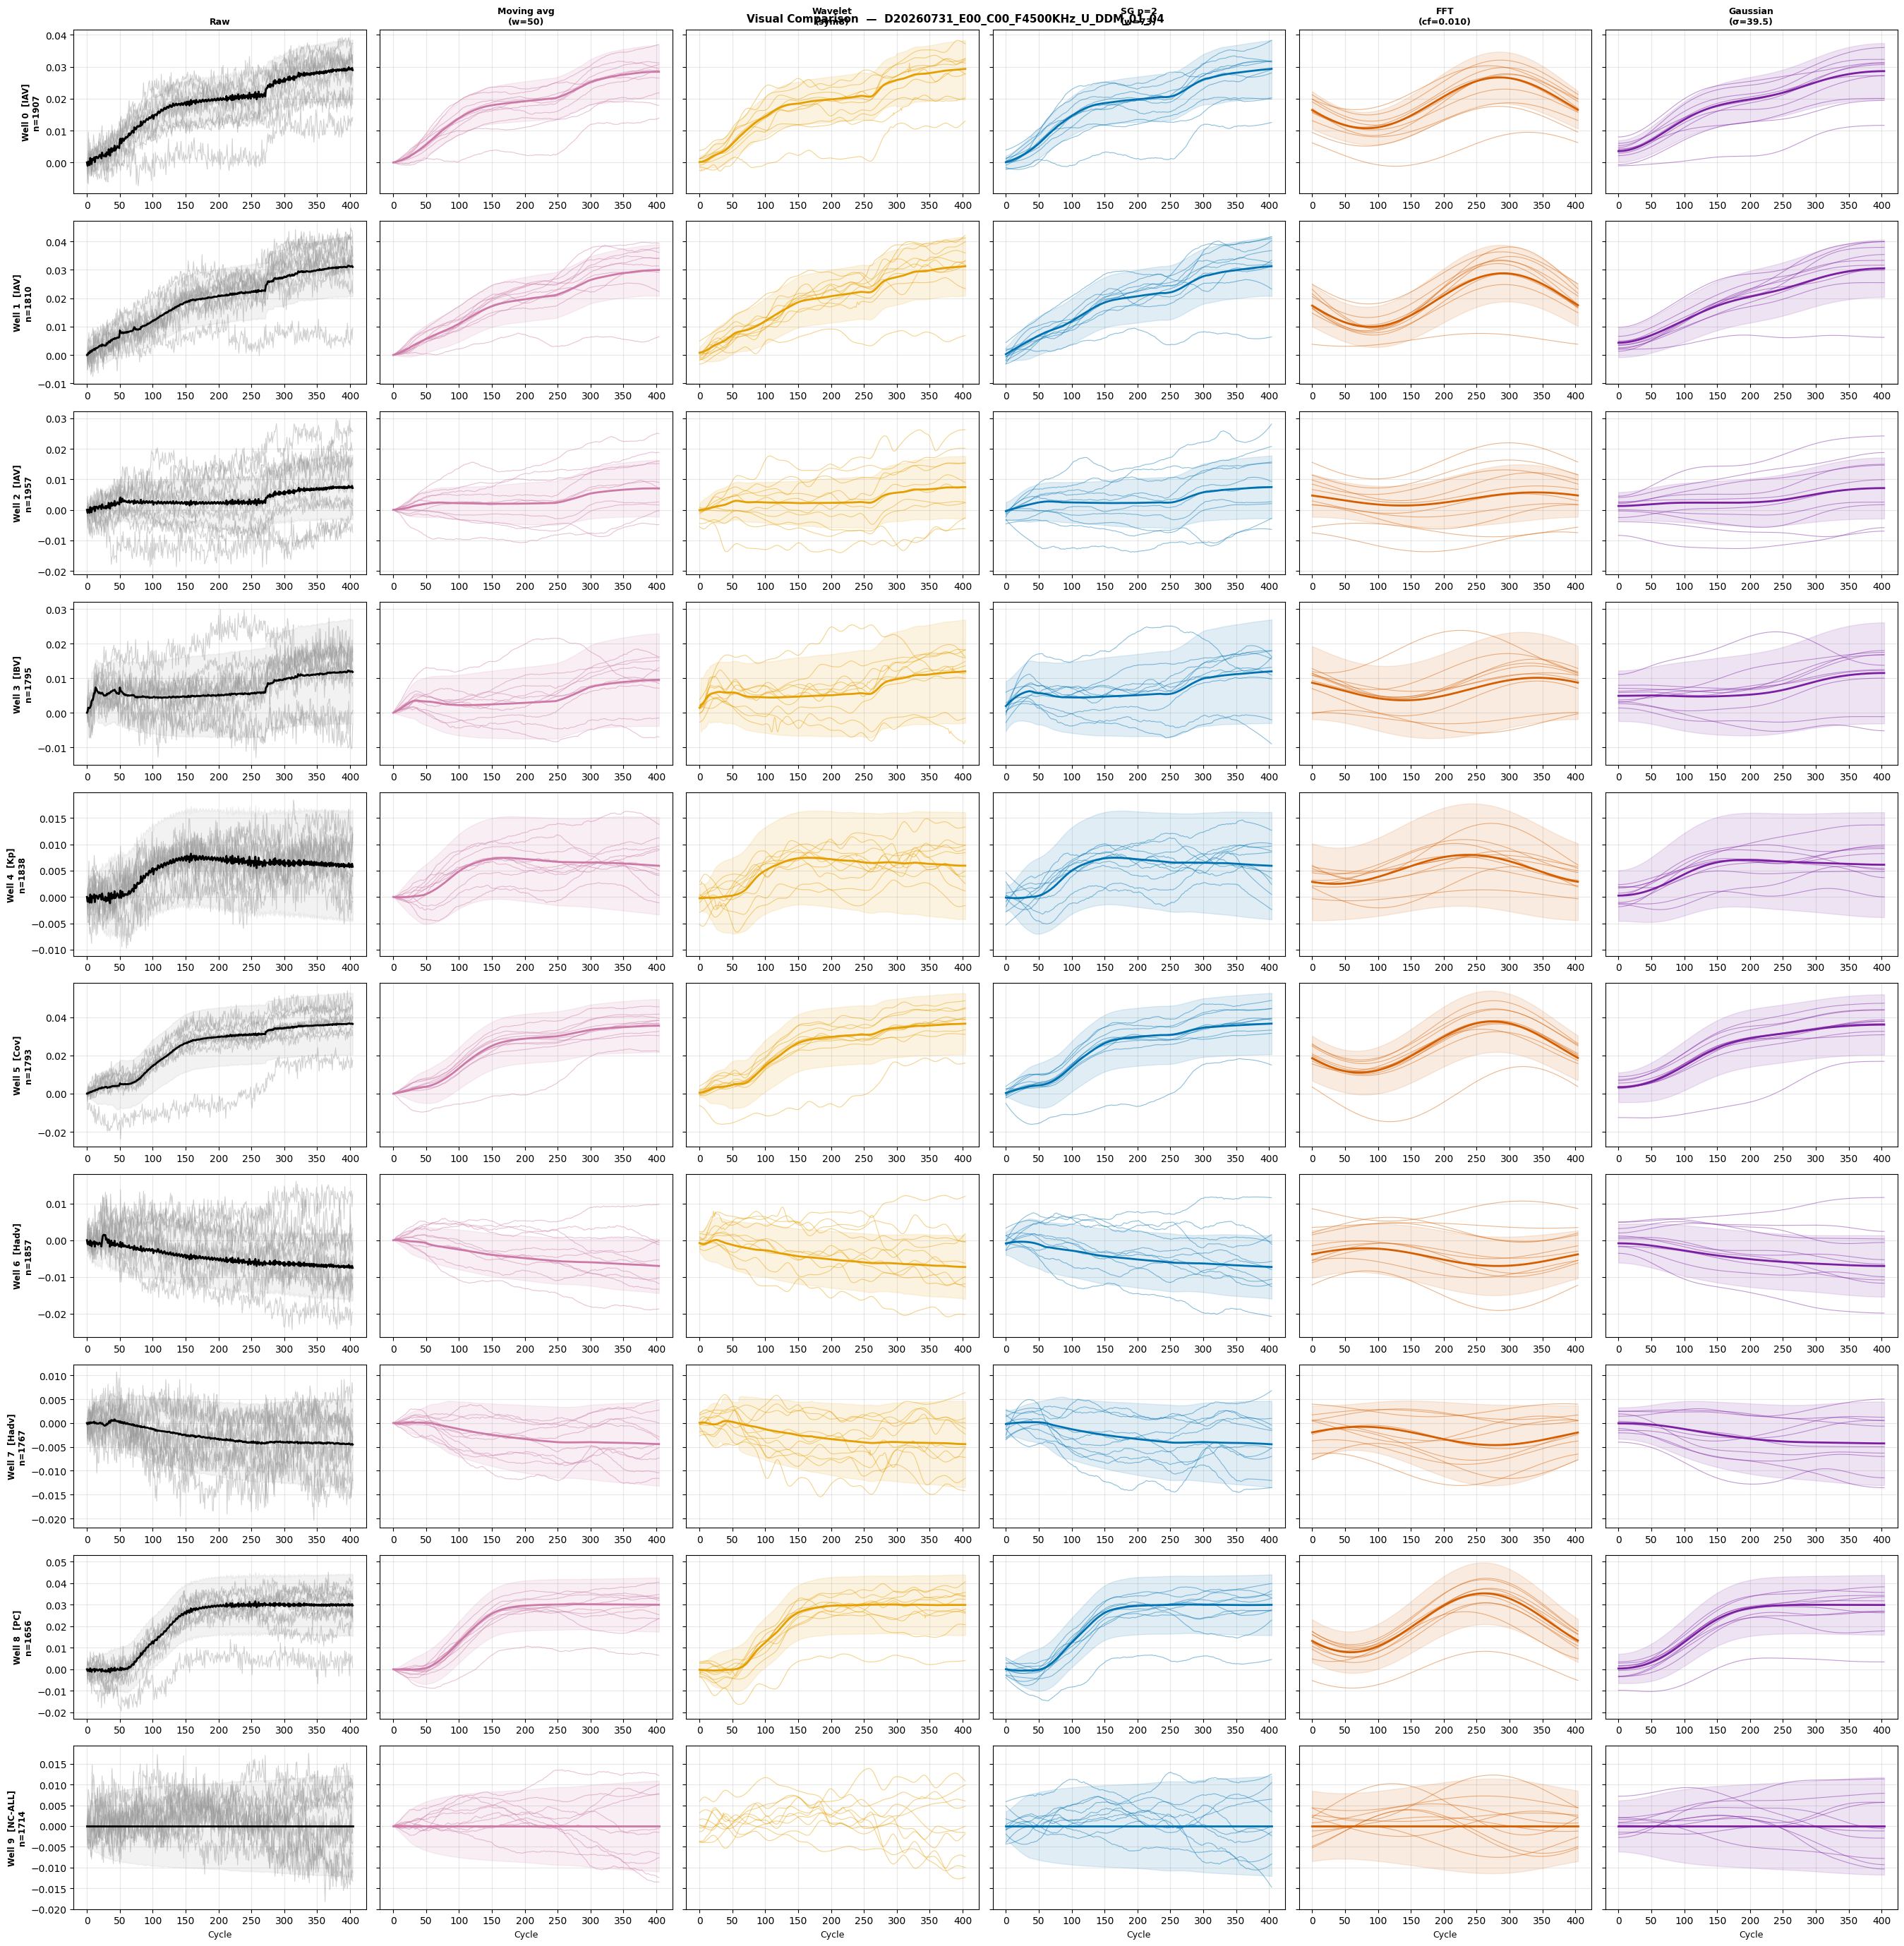

/tmp/ipykernel_235515/1648586650.py:81: RuntimeWarning: invalid value encountered in divide
  sc[0,mi] = np.nanmean(np.where(vn > 0, 10*np.log10(vd/vn), np.nan))
/tmp/ipykernel_235515/1648586650.py:82: RuntimeWarning: invalid value encountered in divide
  sc[1,mi] = np.nanmean(np.where(sr > 0, ns/sr*100, np.nan))
/tmp/ipykernel_235515/1648586650.py:83: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  sc[2,mi] = np.nanmean([pearsonr(raw[i], den[i])[0] for i in range(len(raw))])


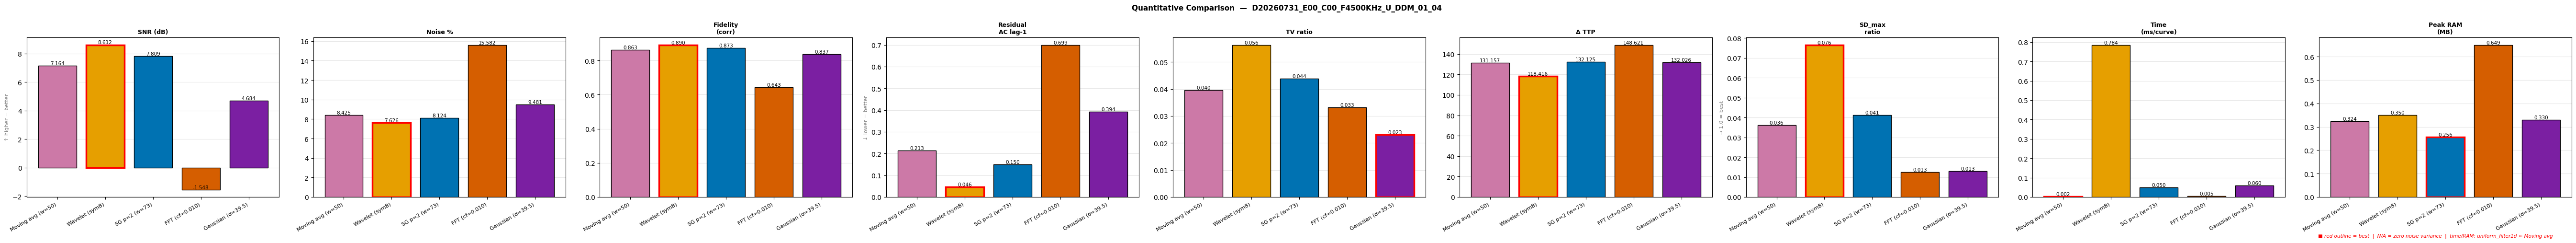


D20260731_E00_C00_F4500KHz_U_DDM_01_04
Metric                      Moving avg (w=50)     Wavelet (sym8)      SG p=2 (w=73)     FFT (cf=0.010)  Gaussian (σ=39.5)
-------------------------------------------------------------------------------------------------------------------------
SNR (dB)                                7.164              *8.612*                7.809               -1.548                4.684   ↑
Noise %                                 8.425              *7.626*                8.124               15.582                9.481   ↓
Fidelity (corr)                         0.863              *0.890*                0.873                0.643                0.837   ↑
Residual AC lag-1                       0.213              *0.046*                0.150                0.699                0.394   ↓
TV ratio                                0.040                0.056                0.044                0.033              *0.023*   ↓
Δ TTP                                 131.157 

In [10]:
from scipy.stats import pearsonr

METHOD_KEYS   = ['smoothed', 'wavelet', 'sg', 'fft', 'gaussian']
METHOD_COLORS = ['#CC79A7', '#E69F00', '#0072B2', '#D55E00', '#7B1FA2']

def _labels():
    return [
        f'Moving avg\n(w={config.WINDOW_SIZE_ORI})',
        f'Wavelet\n({WAVELETS[0]})',
        f'SG p={SG_POLYORDER}\n(w={SG_OPTIMAL_W})',
        f'FFT\n(cf={FFT_CUTOFF:.3f})',
        f'Gaussian\n(\u03c3={GAUSS_SIGMA:.1f})',
    ]

def _ready(r): return all(k in r for k in ('sg', 'fft', 'gaussian'))


def plot_all_methods(folder_name, n_sample=10, seed=42):
    r = results[folder_name]
    if not _ready(r): print(f'[!] Run apply cell first for {folder_name}'); return
    raw, wl, lm = r['raw'], r['well_labels'], r['label_map']
    lbls    = _labels()
    mtitles = ['Raw'] + lbls
    arrays  = [raw, r['smoothed'], r['denoised'][WAVELETS[0]], r['sg'], r['fft'], r['gaussian']]
    colors  = ['#999999'] + METHOD_COLORS
    wells   = sorted(np.unique(wl)); rng = np.random.default_rng(seed)
    fig, axes = plt.subplots(len(wells), len(mtitles),
                             figsize=(4.5*len(mtitles), 2.8*len(wells)),
                             sharey='row', squeeze=False)
    fig.suptitle(f'Visual Comparison  —  {folder_name}', fontsize=11, fontweight='bold')
    x = np.arange(raw.shape[1])
    for ri, well in enumerate(wells):
        mask  = wl == well
        lname = lm.get(int(well), '?') if lm else str(well)
        idx   = rng.choice(np.where(mask)[0], size=min(n_sample, mask.sum()), replace=False)
        for ci, (data, color, title) in enumerate(zip(arrays, colors, mtitles)):
            ax   = axes[ri, ci]
            mean = data[mask].mean(axis=0); std = data[mask].std(axis=0)
            for i in idx: ax.plot(x, data[i], color=color, lw=0.8, alpha=0.45)
            ax.plot(x, mean, color=color if color != '#999999' else 'black', lw=2.0, zorder=3)
            ax.fill_between(x, mean-std, mean+std, color=color, alpha=0.12, zorder=2)
            ax.grid(alpha=0.3)
            if ri == 0:              ax.set_title(title, fontweight='bold', fontsize=9)
            if ci == 0:              ax.set_ylabel(f'Well {well}  [{lname}]\nn={mask.sum()}', fontsize=8.5, fontweight='bold')
            if ri == len(wells)-1:   ax.set_xlabel('Cycle', fontsize=9)
    plt.tight_layout(); plt.show(); plt.close(fig)


def compare_all_methods(folder_name, plot=True):
    r = results[folder_name]
    if not _ready(r): print(f'[!] Run apply cell first for {folder_name}'); return
    raw    = r['raw']
    labels = _labels()
    arrays = [r['smoothed'], r['denoised'][WAVELETS[0]], r['sg'], r['fft'], r['gaussian']]

    def tv(a): return np.abs(np.diff(a, axis=1)).sum(axis=1)
    def ac1(rw, dn):
        res = rw - dn
        return np.nanmean([np.corrcoef((e := res[i]-res[i].mean())[:-1], e[1:])[0, 1]
                           for i in range(len(res)) if res[i].std() > 0])

    mnames = ['SNR (dB)', 'Noise %', 'Fidelity\n(corr)', 'Residual\nAC lag-1',
              'TV ratio', '\u0394 TTP', 'SD_max\nratio']
    better = ['\u2191', '\u2193', '\u2191', '\u2193', '\u2193', '\u2193', '\u21921']

    def best_idx(row, b):
        fin = np.isfinite(row)
        if not fin.any(): return None
        r_ = np.where(fin, row, np.nan)
        if b == '\u2193': return int(np.nanargmin(r_))
        if b == '\u2191': return int(np.nanargmax(r_))
        return int(np.nanargmin(np.abs(r_ - 1.0)))

    n_m  = len(labels)
    sc   = np.full((7, n_m), np.nan)
    draw = np.abs(np.diff(raw, axis=1)); ttp_raw = np.argmax(draw, axis=1).astype(float)
    for mi, den in enumerate(arrays):
        noise = raw - den; ns = np.std(noise, axis=1); sr = raw.max(axis=1) - raw.min(axis=1)
        vd, vn = np.var(den, axis=1), np.var(noise, axis=1)
        dden   = np.abs(np.diff(den, axis=1))
        sc[0,mi] = np.nanmean(np.where(vn > 0, 10*np.log10(vd/vn), np.nan))
        sc[1,mi] = np.nanmean(np.where(sr > 0, ns/sr*100, np.nan))
        sc[2,mi] = np.nanmean([pearsonr(raw[i], den[i])[0] for i in range(len(raw))])
        sc[3,mi] = ac1(raw, den)
        sc[4,mi] = np.nanmean(tv(den) / np.where(tv(raw) > 0, tv(raw), np.nan))
        sc[5,mi] = np.mean(np.abs(ttp_raw - np.argmax(dden, axis=1).astype(float)))
        sc[6,mi] = np.nanmean(dden.max(axis=1) / np.where(draw.max(axis=1)>0, draw.max(axis=1), np.nan))

    bench = r.get('_bench', {}); has_b = bool(bench)
    bms = np.array([bench.get(k,{}).get('ms_per_curve', np.nan) for k in METHOD_KEYS]) if has_b else None
    bmb = np.array([bench.get(k,{}).get('peak_mb',      np.nan) for k in METHOD_KEYS]) if has_b else None

    all_mn = mnames + (['Time\n(ms/curve)', 'Peak RAM\n(MB)'] if has_b else [])
    all_sc = list(sc) + ([bms, bmb] if has_b else [])
    all_bt = better  + (['\u2193', '\u2193'] if has_b else [])

    if plot:
        fig, axes = plt.subplots(1, len(all_mn), figsize=(6*len(all_mn), 5))
        if len(all_mn) == 1: axes = [axes]
        fig.suptitle(f'Quantitative Comparison  —  {folder_name}', fontsize=11, fontweight='bold')
        x = np.arange(n_m)
        for ax, metric, vals, b in zip(axes, all_mn, all_sc, all_bt):
            best = best_idx(vals, b)
            for xi, (val, color) in enumerate(zip(vals, METHOD_COLORS)):
                if np.isnan(val):
                    ax.bar(xi, 1, color='none', edgecolor=color, lw=1.5, ls='--', zorder=3)
                    ax.text(xi, 0.5, 'N/A', ha='center', va='center', fontsize=8, color=color, fontweight='bold')
                else:
                    bar = ax.bar(xi, val, color=color, edgecolor='black', zorder=3)
                    if xi == best: bar[0].set_edgecolor('red'); bar[0].set_linewidth(2.5)
                    ax.text(xi, val, f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)
            ax.set_title(metric, fontweight='bold', fontsize=9)
            ax.set_xticks(x)
            ax.set_xticklabels([l.replace('\n',' ') for l in labels], rotation=30, ha='right', fontsize=8)
            ax.grid(axis='y', alpha=0.3, zorder=0)
        axes[0].set_ylabel('\u2191 higher = better', fontsize=8, color='gray')
        if len(axes) > 3: axes[3].set_ylabel('\u2193 lower = better', fontsize=8, color='gray')
        if len(axes) > 6: axes[6].set_ylabel('\u2192 1.0 = best',     fontsize=8, color='gray')
        note = '\u25a0 red outline = best  |  N/A = zero noise variance'
        if has_b: note += '  |  time/RAM: uniform_filter1d \u2248 Moving avg'
        fig.text(0.99, 0.01, note, ha='right', fontsize=7.5, color='red', style='italic')
        fig.tight_layout(); plt.show(); plt.close(fig)

    col_w  = max(len(l.replace('\n',' ')) for l in labels) + 2
    header = f'{"Metric":<26}' + ''.join(f'{l.replace(chr(10)," "):>{col_w}}' for l in labels)
    sep    = '-' * len(header)
    print(f'\n{folder_name}'); print(header); print(sep)
    for metric, row, b in zip(all_mn, all_sc, all_bt):
        best   = best_idx(row, b)
        cells_ = [f'{"N/A" if np.isnan(v) else (f"*{v:.3f}*" if i==best else f"{v:.3f}"):>{col_w}}'
                  for i, v in enumerate(row)]
        print(f'{metric.replace(chr(10)," "):<26}{"  ".join(cells_)}   {b}')
    print(sep)


for folder_name in results:
    plot_all_methods(folder_name)
    compare_all_methods(folder_name, plot=True)
